# Regressão para Prever o Movimento

**1. Definição do Alvo (Label):**

O alvo não seria mais uma categoria, mas sim um número contínuo. Você tem algumas ótimas opções para o seu label:

*   **Opção A: "Tamanho da Vela" (Volatilidade)**
    *   **Cálculo:** `label = Maxima_11h_12h - Minima_11h_12h`
    *   **O que prevê:** A volatilidade ou o range total do movimento na próxima hora. O modelo tentaria prever se a próxima hora será "calma" (valor baixo) ou "explosiva" (valor alto).
    *   **Vantagem:** É um problema de regressão mais "fácil", pois o valor é sempre positivo.
    *   **Desvantagem:** Não informa a **direção** do movimento.

*   **Opção B (Mais Comum): "Retorno Direcional"**
    *   **Cálculo:** `label = Fechamento_12h - Abertura_11h`
    *   **O que prevê:** O movimento direcional líquido em pontos.
        *   Um valor positivo grande significa uma forte alta.
        *   Um valor negativo grande significa uma forte baixa.
        *   Um valor próximo de zero significa um movimento lateral.
    *   **Vantagem:** É a previsão mais completa, pois contém tanto a **magnitude** quanto a **direção** do movimento.
    *   **Desvantagem:** É um problema de regressão mais difícil, pois o modelo precisa acertar o sinal (positivo/negativo) e o valor.

*   **Opção C (Híbrida): Prever a Volatilidade e a Direção Separadamente**
    *   Você poderia treinar dois modelos: um de regressão para prever o "Tamanho da Vela" (Opção A) e um de classificação para prever a direção ("Alta", "Baixa", "Lateral"). Esta é uma abordagem mais complexa, mas pode ser eficaz.

**Recomendação:** Comece com a **Opção B ("Retorno Direcional")**. É a mais informativa e a que mais se aproxima de um sistema de trading real.

## Mudanças Necessárias no seu Pipeline

1.  **Criação do Label (Alvo `Y`):**
    *   Em vez de toda a lógica de `np.select` para criar "Compra", "Venda", "Lateral", você terá uma única linha:
    ```python
    # Na seção de geração de labels
    df_janela_alvo = df_completo.between_time('11:00', '11:59')
    daily_agg_label = df_janela_alvo.resample('D').agg(
        Abertura_11h=('Abertura', 'first'),
        Fechamento_12h=('Fechamento', 'last') # Ajustar para o fechamento final
    )
    daily_agg_label.dropna(inplace=True)
    
    # A nova label de regressão
    daily_agg_label['retorno_direcional'] = daily_agg_label['Fechamento_12h'] - daily_agg_label['Abertura_11h']
    
    # Y será esta coluna
    Y = daily_agg_label['retorno_direcional']
    ```

2.  **Configuração do Modelo (Exemplo com XGBoost):**
    *   O `objective` do XGBoost muda de `multi:softmax` para `reg:squarederror`.
    *   A métrica de avaliação (`eval_metric`) muda de `mlogloss` para `rmse` (Root Mean Squared Error).
    *   O `num_class` é removido.
    ```python
    # Dentro da função objective do Optuna
    params = {
        'objective': 'reg:squarederror', # <-- MUDANÇA
        'eval_metric': 'rmse',           # <-- MUDANÇA
        'booster': 'dart',
        # ... outros hiperparâmetros ...
    }
    ```

3.  **Avaliação do Modelo:**
    *   Você não usará mais `accuracy_score`, `classification_report` ou `confusion_matrix`.
    *   As métricas de avaliação para regressão são:
        *   **RMSE (Root Mean Squared Error):** A raiz quadrada do erro médio quadrático. É a métrica mais comum. Te diz, em média, quantos *pontos* o seu modelo erra a previsão. Um RMSE de 200 significa que suas previsões estão, em média, a 200 pontos do valor real. O Optuna tentará **minimizar** esta métrica.
        *   **MAE (Mean Absolute Error):** O erro médio absoluto. Mais fácil de interpretar que o RMSE.
        *   **R² (R-squared):** Indica a proporção da variância no alvo que é previsível a partir das features. Um valor de 1.0 é uma previsão perfeita, 0.0 significa que o modelo não é melhor do que prever a média.

## Prós e Contras da Abordagem de Regressão

**Prós:**

*   **Mais Granularidade:** Em vez de uma previsão "binária" (Compra ou não), você obtém uma previsão de magnitude. Isso permite estratégias mais sofisticadas (ex: "entrar com mais contratos se a previsão for > 500 pontos").
*   **Métricas de Erro Claras:** Um RMSE de 200 pontos é uma medida de erro diretamente interpretável e acionável.
*   **Pode ser Mais Fácil de Aprender:** Às vezes, é mais fácil para um modelo aprender uma relação contínua do que uma fronteira de decisão categórica e rígida.

**Contras:**

*   **Sensibilidade a Outliers no Alvo:** Um único dia com um movimento de 5000 pontos pode distorcer completamente o treinamento e a avaliação do modelo. Pode ser necessário tratar ou transformar o alvo (ex: usando `np.log`).
*   **Interpretação para Trading:** Você ainda precisa de uma regra para transformar a previsão numérica em uma ação de trading. Ex: "Se a previsão for > 200, compre. Se for < -200, venda. Senão, não faça nada". Isso introduz outro parâmetro a ser otimizado.

# Arquitetura **CNN-LSTM** para um problema de regressão.

A única coisa que muda é a "cabeça" da rede (a última camada) e a "linguagem" que ela usa para aprender (a função de perda).

## Como Adaptar o Modelo CNN-LSTM para Regressão

Imagine sua arquitetura atual como uma fábrica:

1.  **Entrada:** Os dados sequenciais (o "vídeo" de 120 candles) e os dados de contexto.
2.  **Processamento Interno:** As camadas CNN extraem padrões, a LSTM entende a sequência, e as camadas densas combinam tudo.
3.  **Saída Atual (Classificação):** A última camada é uma `Dense(3, activation='softmax')` e a função de perda é `categorical_crossentropy`. Isso força a fábrica a produzir uma de três respostas: "Compra", "Venda" ou "Lateral".

Para mudar para regressão, você simplesmente troca a seção de saída da fábrica.

**As Mudanças Necessárias no seu Código CNN-LSTM:**

1.  **Preparação do Alvo (`y`):**
    *   O seu `y` não será mais `np.argmax(y_one_hot, axis=1)`.
    *   Ele será a coluna contínua que você calculou, por exemplo: `y = daily_agg_label['retorno_direcional'].values`.
    *   O formato de `y` será `(numero_de_dias,)`.

2.  **Arquitetura do Modelo (Dentro da função `objective`):**
    *   **Última Camada:** A mudança mais importante.
        *   **De:** `outputs = Dense(3, activation='softmax')(x)`
        *   **Para:** `outputs = Dense(1, activation='linear')(x)`
            *   `Dense(1)`: A saída agora é um **único neurônio**, que produzirá um único número (a sua previsão de retorno em pontos).
            *   `activation='linear'`: Usamos uma ativação linear (ou simplesmente nenhuma ativação, `activation=None`) porque queremos que a saída possa ser qualquer número real (positivo, negativo, grande ou pequeno), não uma probabilidade entre 0 e 1.

3.  **Compilação do Modelo:**
    *   **Função de Perda (Loss Function):**
        *   **De:** `loss='categorical_crossentropy'`
        *   **Para:** `loss='mean_squared_error'` (ou simplesmente `'mse'`). Esta é a função de perda padrão para regressão, que o modelo tentará minimizar.
    *   **Métricas:**
        *   **De:** `metrics=['accuracy']`
        *   **Para:** `metrics=['mae']` (Mean Absolute Error). Durante o treinamento, é útil monitorar o MAE, pois ele te diz, em pontos, o quão longe as previsões estão do valor real, em média.

4.  **Avaliação do Modelo (Função `objective` e Avaliação Final):**
    *   O Optuna não irá mais maximizar a `accuracy`. Ele deverá **minimizar** a métrica de validação.
    *   **De:** `study = optuna.create_study(direction='maximize')` e `return val_accuracy`
    *   **Para:** `study = optuna.create_study(direction='minimize')` e `return val_loss` (ou `val_mae`). Minimizar o erro (loss) é o objetivo da regressão.
    *   Na avaliação final, você não usará `classification_report` ou `confusion_matrix`. Em vez disso, você calculará `mean_squared_error` e `mean_absolute_error` e talvez plotará um gráfico de dispersão comparando os valores previstos com os valores reais.


# Criando o dataset

Este script é responsável por toda a parte de Engenharia de Dados. Ele carrega os dados brutos, cria as features, define o label de regressão e salva um único arquivo CSV final, pronto para ser consumido pelo modelo.

1.  **Carrega e Junta os Dados:** Carrega os dados de 1 minuto do WIN e do WDO.
2.  **Cria o Label de Regressão:** Define o alvo como o "Tamanho da Vela" (Volatilidade) na hora seguinte (11:00-11:59).
3.  **Engenharia de Features Completa:** Gera as features de Contexto, Cíclicas e Sequenciais.

In [9]:
# ==============================================================================
# SCRIPT GERADOR DE DATASET PARA REGRESSÃO (VERSÃO MODIFICADA)
# Objetivo: Criar um dataset com um label de regressão (retorno direcional)
#           e com a ordem de colunas otimizada.
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tenta usar a biblioteca TA-Lib se estiver instalada
try:
    import talib
    TALIB_INSTALLED = True
    print("Biblioteca TA-Lib encontrada.")
except ImportError:
    TALIB_INSTALLED = False
    print("AVISO: Biblioteca TA-Lib não encontrada. O cálculo de alguns indicadores pode falhar.")

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_INDICE = 'WIN$N_M5_BRUTO.csv'
NOME_ARQUIVO_DOLAR = 'WDO$N_M5_BRUTO.csv'
NOME_ARQUIVO_SAIDA_FINAL = 'dataset_regressao_hibrido.csv' 

abertura_features = '09:00'
fechamento_features = '10:55'
abertura_labels = '11:00'
fechamento_labels = '11:55' 
quantidade_velas = 24

# --- ETAPA 1: CARREGAMENTO E JUNÇÃO DOS DADOS BRUTOS ---
print("\n--- ETAPA 1: CARREGANDO E JUNTANDO DADOS DE ÍNDICE E DÓLAR ---")
# (Esta etapa permanece idêntica)
def carregar_e_preparar_ativo(nome_arquivo, sufixo=''):
    df = pd.read_csv(nome_arquivo, sep=';', parse_dates=['datetime'], index_col='datetime')
    colunas_numericas = ['Abertura', 'Maxima', 'Minima', 'Fechamento', 'Volume_Real', 'Volume_Tick']
    for col in colunas_numericas:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(subset=colunas_numericas, inplace=True)
    if sufixo:
        df = df.add_suffix(sufixo)
    return df

try:
    df_indice = carregar_e_preparar_ativo(NOME_ARQUIVO_INDICE)
    df_dolar = carregar_e_preparar_ativo(NOME_ARQUIVO_DOLAR, sufixo='_dolar')
    df_completo = df_indice.join(df_dolar, how='inner')
    print(f"Dados de Índice e Dólar carregados e juntados. Total de candles sincronizados: {len(df_completo)}")
except Exception as e:
    print(f"ERRO na ETAPA 1: {e}")
    exit()

# --- ETAPA 2: CÁLCULO DAS FEATURES DE CONTEXTO DIÁRIO ---
print("\n--- ETAPA 2: CALCULANDO FEATURES DE CONTEXTO DIÁRIO ---")
# (Esta etapa permanece idêntica)
def calcular_contexto_diario_completo(df, sufixo=''):
    cols = {
        'Abertura': f'Abertura{sufixo}', 'Maxima': f'Maxima{sufixo}',
        'Minima': f'Minima{sufixo}', 'Fechamento': f'Fechamento{sufixo}'
    }
    df_diario = df.resample('D').agg(
       Abertura=(cols['Abertura'], 'first'), Maxima=(cols['Maxima'], 'max'),
       Minima=(cols['Minima'], 'min'), Fechamento=(cols['Fechamento'], 'last')
    ).dropna()
    
    if sufixo:
        df_diario = df_diario.rename(columns={k: f"{k}{sufixo}" for k in ['Abertura', 'Maxima', 'Minima', 'Fechamento']})

    high_low = df_diario[f'Maxima{sufixo}'] - df_diario[f'Minima{sufixo}']
    high_close = np.abs(df_diario[f'Maxima{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1))
    low_close = np.abs(df_diario[f'Minima{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df_diario[f'atr_dia_anterior{sufixo}'] = true_range.rolling(window=14, min_periods=1).mean().shift(1)
    
    df_diario[f'range_dia_anterior{sufixo}'] = (df_diario[f'Maxima{sufixo}'].shift(1) - df_diario[f'Minima{sufixo}'].shift(1)) / df_diario[f'Abertura{sufixo}'].shift(1)
    df_diario[f'mm20_diaria{sufixo}'] = df_diario[f'Fechamento{sufixo}'].rolling(window=20).mean()
    df_diario[f'gap{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1)) / df_diario[f'Fechamento{sufixo}'].shift(1)
    df_diario[f'posicao_range_d1{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'Minima{sufixo}'].shift(1)) / (df_diario[f'Maxima{sufixo}'].shift(1) - df_diario[f'Minima{sufixo}'].shift(1))
    df_diario[f'distancia_mm20{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'mm20_diaria{sufixo}'].shift(1)) / df_diario[f'mm20_diaria{sufixo}'].shift(1)
    
    df_diario.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df_diario

df_contexto_win = calcular_contexto_diario_completo(df_completo)
df_contexto_dolar = calcular_contexto_diario_completo(df_completo, sufixo='_dolar')
df_contexto_geral = df_contexto_win.join(df_contexto_dolar, how='inner')

features_contexto_diarias = [
    'gap', 'range_dia_anterior', 'atr_dia_anterior', 'posicao_range_d1', 'distancia_mm20',
    'gap_dolar', 'range_dia_anterior_dolar', 'atr_dia_anterior_dolar', 'posicao_range_d1_dolar', 'distancia_mm20_dolar'
]
df_contexto_geral.dropna(subset=features_contexto_diarias, inplace=True)
print("Features de contexto diário completas calculadas.")

# --- ETAPA 3: GERAÇÃO DO LABEL DE REGRESSÃO ---
print("\n--- ETAPA 3: GERANDO O LABEL DE REGRESSÃO ---")

# Seleciona a janela de tempo para o nosso alvo (11:00 a 11:59)
df_janela_alvo = df_completo.between_time(abertura_labels, fechamento_labels)

# Agrega por dia para encontrar a abertura da primeira vela e o fechamento da última
daily_agg_label = df_janela_alvo.resample('D').agg(
    Abertura_primeira_vela=('Abertura', 'first'),
    Fechamento_ultima_vela=('Fechamento', 'last')
).dropna()

# Calcula o label de regressão: o movimento direcional em pontos
daily_agg_label['retorno_direcional_alvo'] = daily_agg_label['Fechamento_ultima_vela'] - daily_agg_label['Abertura_primeira_vela']

print(f"Label de regressão 'retorno_direcional_alvo' criado para {len(daily_agg_label)} dias.")
print("Amostra do label gerado:")
display(daily_agg_label.head())

# --- ETAPA 4: CÁLCULO DAS FEATURES SEQUENCIAIS ---
print("\n--- ETAPA 4: CALCULANDO TODAS AS FEATURES SEQUENCIAIS ---")
# (Esta etapa permanece idêntica)
df_completo.replace(0, 1e-9, inplace=True)
for suffix in ['', '_dolar']:
    df_completo[f'mag_decisao{suffix}'] = abs(df_completo[f'Fechamento{suffix}'] - df_completo[f'Abertura{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'mov_direcional{suffix}'] = np.sign(df_completo[f'Fechamento{suffix}'] - df_completo[f'Abertura{suffix}'])
    df_completo[f'pavio_superior{suffix}'] = (df_completo[f'Maxima{suffix}'] - df_completo[[f'Abertura{suffix}', f'Fechamento{suffix}']].max(axis=1)) / df_completo[f'Abertura{suffix}']
    df_completo[f'pavio_inferior{suffix}'] = (df_completo[[f'Abertura{suffix}', f'Fechamento{suffix}']].min(axis=1) - df_completo[f'Minima{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'range{suffix}'] = (df_completo[f'Maxima{suffix}'] - df_completo[f'Minima{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'volume_real_norm{suffix}'] = df_completo[f'Volume_Real{suffix}'] / df_completo[f'Volume_Real{suffix}'].rolling(window=50, min_periods=1).mean()
    df_completo[f'volume_tick_norm{suffix}'] = df_completo[f'Volume_Tick{suffix}'] / df_completo[f'Volume_Tick{suffix}'].rolling(window=50, min_periods=1).mean()
    df_completo[f'tamanho_medio_ordem{suffix}'] = df_completo[f'Volume_Real{suffix}'] / df_completo[f'Volume_Tick{suffix}']
    ma_3 = df_completo[f'Fechamento{suffix}'].rolling(window=3).mean()
    ma_9 = df_completo[f'Fechamento{suffix}'].rolling(window=9).mean()
    df_completo[f'diferenca_MA{suffix}'] = (ma_3 - ma_9) / df_completo[f'Fechamento{suffix}']
    if TALIB_INSTALLED:
        df_completo[f'RSI{suffix}'] = talib.RSI(df_completo[f'Fechamento{suffix}'], timeperiod=14)
        macd, macdsignal, _ = talib.MACD(df_completo[f'Fechamento{suffix}'], fastperiod=12, slowperiod=26, signalperiod=9)
        df_completo[f'MACD{suffix}'] = macd - macdsignal
    else: # Implementação alternativa simples
        delta = df_completo[f'Fechamento{suffix}'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df_completo[f'RSI{suffix}'] = 100 - (100 / (1 + rs))
        ema_fast = df_completo[f'Fechamento{suffix}'].ewm(span=12, adjust=False).mean()
        ema_slow = df_completo[f'Fechamento{suffix}'].ewm(span=26, adjust=False).mean()
        macd_line = ema_fast - ema_slow
        signal_line = macd_line.ewm(span=9, adjust=False).mean()
        df_completo[f'MACD{suffix}'] = macd_line - signal_line
df_completo['correlacao_movel_WIN_WDO'] = df_completo['Fechamento'].rolling(window=24, min_periods=10).corr(df_completo['Fechamento_dolar'])
df_completo['ratio_vol_WIN_WDO'] = df_completo['Volume_Real'] / df_completo['Volume_Real_dolar']
df_completo.dropna(inplace=True)
print("Todas as features sequenciais foram calculadas.")

# --- ETAPA 5: ACHATAMENTO E REORDENAÇÃO HÍBRIDA ---
print("\n--- ETAPA 5: ACHATANDO DADOS NA ORDEM HÍBRIDA ---")
# (Esta etapa permanece idêntica)
features_sequenciais_nomes = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior', 'range', 
    'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem', 'diferenca_MA', 'RSI', 'MACD',
    'mag_decisao_dolar', 'mov_direcional_dolar', 'pavio_superior_dolar', 'pavio_inferior_dolar', 'range_dolar', 
    'volume_real_norm_dolar', 'volume_tick_norm_dolar', 'tamanho_medio_ordem_dolar', 'diferenca_MA_dolar', 'RSI_dolar', 'MACD_dolar',
    'correlacao_movel_WIN_WDO', 'ratio_vol_WIN_WDO'
]

df_janela_entrada = df_completo.between_time(abertura_features, fechamento_features).copy()
dias_com_candles_suficientes = df_janela_entrada.index.normalize().value_counts()
dias_validos_counts = dias_com_candles_suficientes[dias_com_candles_suficientes == quantidade_velas].index
dias_finais = sorted(list(set(dias_validos_counts) & set(df_contexto_geral.index) & set(daily_agg_label.index)))
df_janela_filtrada = df_janela_entrada[df_janela_entrada.index.normalize().isin(dias_finais)]
grouped_by_day = df_janela_filtrada.groupby(df_janela_filtrada.index.normalize())
colunas_hibridas = [f'{feature}_c{i}' for feature in features_sequenciais_nomes for i in range(1, quantidade_velas+1)]
lista_dfs_achatados = []
dias_ordenados = sorted(grouped_by_day.groups.keys())
for feature in features_sequenciais_nomes:
    dados_feature = [group[feature].values for day, group in grouped_by_day]
    df_feature_achatada = pd.DataFrame(dados_feature, index=dias_ordenados)
    lista_dfs_achatados.append(df_feature_achatada)
df_features_sequenciais = pd.concat(lista_dfs_achatados, axis=1)
df_features_sequenciais.columns = colunas_hibridas
print("Achatamento e reordenação para o formato híbrido concluídos.")

# --- ETAPA 6: FEATURES CÍCLICAS E JUNÇÃO FINAL COM NOVA ORDEM ---
print("\n--- ETAPA 6: CRIANDO FEATURES CÍCLICAS E JUNTANDO TUDO ---")
df_tempo = pd.DataFrame(index=pd.to_datetime(dias_finais))
df_tempo['mes_sin'] = np.sin(2 * np.pi * df_tempo.index.month / 12)
df_tempo['mes_cos'] = np.cos(2 * np.pi * df_tempo.index.month / 12)
dias_no_mes = df_tempo.index.days_in_month
df_tempo['dia_mes_sin'] = np.sin(2 * np.pi * df_tempo.index.day / dias_no_mes)
df_tempo['dia_mes_cos'] = np.cos(2 * np.pi * df_tempo.index.day / dias_no_mes)
df_tempo['dia_semana_sin'] = np.sin(2 * np.pi * df_tempo.index.dayofweek / 7)
df_tempo['dia_semana_cos'] = np.cos(2 * np.pi * df_tempo.index.dayofweek / 7)
features_ciclicas = df_tempo[['mes_sin', 'mes_cos', 'dia_mes_sin', 'dia_mes_cos', 'dia_semana_sin', 'dia_semana_cos']]

# Junta os blocos de features
df_ciclicas_contexto = features_ciclicas.join(df_contexto_geral[features_contexto_diarias], how='inner')
df_todas_as_features = df_ciclicas_contexto.join(df_features_sequenciais, how='inner')

# Junta as features com o label de regressão
df_dataset_final = df_todas_as_features.join(daily_agg_label[['retorno_direcional_alvo']], how='inner')

print("Junção final de todos os blocos de features e label concluída.")

# --- ETAPA 7: SALVAR E EXIBIR O DATASET FINAL ---
print(f"\n--- ETAPA 7: SALVANDO E EXIBINDO O RESULTADO ---")
df_dataset_final.to_csv(NOME_ARQUIVO_SAIDA_FINAL, sep=';')
print(f"Arquivo salvo como: '{NOME_ARQUIVO_SAIDA_FINAL}'")
print(f"Dimensões do DataFrame final (dias, colunas): {df_dataset_final.shape}")
print(f"Total de dias válidos no dataset final: {len(df_dataset_final)}")
pd.set_option('display.max_columns', 20)
print("\nAmostra do dataset final (início das colunas cíclicas/contexto e a coluna de label no final):")
# Mostra as primeiras colunas e a última para verificação
display(df_dataset_final.iloc[:, list(range(10)) + [-1]].head())
pd.reset_option('display.max_columns')


Biblioteca TA-Lib encontrada.

--- ETAPA 1: CARREGANDO E JUNTANDO DADOS DE ÍNDICE E DÓLAR ---
Dados de Índice e Dólar carregados e juntados. Total de candles sincronizados: 96872

--- ETAPA 2: CALCULANDO FEATURES DE CONTEXTO DIÁRIO ---
Features de contexto diário completas calculadas.

--- ETAPA 3: GERANDO O LABEL DE REGRESSÃO ---
Label de regressão 'retorno_direcional_alvo' criado para 868 dias.
Amostra do label gerado:


,Abertura_primeira_vela,Fechamento_ultima_vela,retorno_direcional_alvo
datetime,,,
2022-07-25,100915.0,100795.0,-120.0
2022-07-26,101220.0,100895.0,-325.0
2022-07-27,100770.0,101020.0,250.0
2022-07-28,101985.0,101960.0,-25.0
2022-07-29,103245.0,103645.0,400.0



--- ETAPA 4: CALCULANDO TODAS AS FEATURES SEQUENCIAIS ---
Todas as features sequenciais foram calculadas.

--- ETAPA 5: ACHATANDO DADOS NA ORDEM HÍBRIDA ---
Achatamento e reordenação para o formato híbrido concluídos.

--- ETAPA 6: CRIANDO FEATURES CÍCLICAS E JUNTANDO TUDO ---
Junção final de todos os blocos de features e label concluída.

--- ETAPA 7: SALVANDO E EXIBINDO O RESULTADO ---
Arquivo salvo como: 'dataset_regressao_hibrido.csv'
Dimensões do DataFrame final (dias, colunas): (839, 593)
Total de dias válidos no dataset final: 839

Amostra do dataset final (início das colunas cíclicas/contexto e a coluna de label no final):


,mes_sin,mes_cos,dia_mes_sin,dia_mes_cos,dia_semana_sin,dia_semana_cos,gap,range_dia_anterior,atr_dia_anterior,posicao_range_d1,retorno_direcional_alvo
2022-08-19,-0.866025,-0.5,-0.651372,-0.758758,-0.433884,-0.900969,-0.009647,0.009932,1990.714286,-0.273913,-385.0
2022-08-22,-0.866025,-0.5,-0.968077,-0.250653,0.000000,1.000000,-0.006203,0.021221,2107.142857,-0.278689,125.0
2022-08-23,-0.866025,-0.5,-0.998717,-0.050649,0.781831,0.623490,0.005961,0.009675,2035.000000,1.239631,220.0
2022-08-24,-0.866025,-0.5,-0.988468,0.151428,0.974928,-0.222521,-0.000435,0.021935,2127.142857,0.933468,235.0
2022-08-25,-0.866025,-0.5,-0.937752,0.347305,0.433884,-0.900969,0.006403,0.012154,2008.928571,0.892473,-205.0


# Tratando o dataset

# Trreinando o modelo

Este script carrega o dataset pré-processado, prepara os dados para o modelo, executa a otimização com Optuna, treina o melhor modelo e avalia sua performance.

1.  **Otimização com Optuna:** Usa o Optuna para encontrar os melhores hiperparâmetros para um modelo **CNN-LSTM de Múltiplas Entradas** focado em **regressão**.
2.  **Treinamento do Modelo Final:** Treina o modelo campeão com os melhores parâmetros encontrados.
3.  **Avaliação e Métricas:** Avalia o modelo final no conjunto de teste usando métricas de regressão (RMSE, MAE) e visualizações apropriadas.

## Pontos Fortes (O que está excelente):
1.  **Reconstrução Correta do Tensor 3D (Etapa 1.3):**
    *   Esta é a parte mais crítica e complexa do script, e você a implementou de forma **impecável**.
    *   A lógica de identificar as features de contexto e os nomes base das features sequenciais é robusta.
    *   O loop que preenche o tensor `X_seq` pré-alocado (`np.zeros(...)`) é a maneira correta e eficiente de "desachatar" os dados, transformando o formato 2D do CSV de volta para o formato 3D (`amostras, timesteps, features`) que a CNN/LSTM exige.

2.  **Uso Correto da Arquitetura de Múltiplas Entradas:**
    *   A função `create_model` define corretamente duas entradas (`input_seq`, `input_context`).
    *   Ela processa cada entrada em seu próprio "ramo" (o ramo CNN-LSTM para os dados sequenciais e o ramo `Dense` para os dados de contexto).
    *   A camada `concatenate` junta os resultados dos dois ramos antes de passá-los para as camadas finais. Esta é a implementação canônica e correta de um modelo de múltiplas entradas.

3.  **Adaptação para Regressão:**
    *   A camada de saída `Dense(1, activation='linear')` está perfeitamente configurada para um problema de regressão.
    *   A compilação com `loss='mean_squared_error'` e a otimização do Optuna para `direction='minimize'` estão corretas, pois o objetivo é minimizar o erro.

4.  **Padronização Robusta (Etapa 1.5):**
    *   Você aplicou o `StandardScaler` separadamente para os dados de contexto e sequenciais, o que é a abordagem correta.
    *   Crucialmente, você treinou o scaler (`.fit()`) **apenas no conjunto de treino** e depois aplicou (`.transform()`) nos conjuntos de validação e teste. Isso evita o "vazamento de dados" (data leakage) e garante que a avaliação do modelo seja justa.

5.  **Avaliação Completa (Etapas 4 e 5):**
    *   O uso de métricas de regressão como `RMSE`, `MAE` e `R²` é o padrão da indústria e fornece uma visão completa do desempenho.
    *   Os gráficos de "Previsões vs. Real" e a "Distribuição dos Resíduos" são as visualizações mais importantes para entender o comportamento do modelo de regressão. Eles ajudam a responder perguntas como: "O modelo tem um viés (bias)?", "Ele tende a superestimar ou subestimar?", "Os erros são normalmente distribuídos?".

## Observações Analíticas e Pontos de Atenção:

*   **O Desafio do `R²` Negativo:** Não se assuste se, nos resultados finais, você obtiver um valor de **R² negativo**. Em machine learning (diferente da estatística linear clássica), um R² negativo é possível e tem um significado claro: **o seu modelo é pior do que um modelo ingênuo que simplesmente prevê a média de todos os alvos.** Isso é um sinal forte de que o modelo não conseguiu generalizar e aprender um padrão útil nos dados de teste.

*   **Interpretação do RMSE/MAE:** O valor do RMSE e do MAE deve ser interpretado no contexto do seu alvo (`tamanho_vela_alvo`). Se o tamanho médio da vela alvo é de 500 pontos e o seu modelo tem um MAE de 150 pontos, isso pode ser um resultado muito bom. Se o tamanho médio é de 200 e o MAE é 180, o modelo é quase inútil. Sempre compare o erro com a escala do que você está tentando prever.

*   **Ajuste do `pool_size` na CNN:** A camada `MaxPooling1D(pool_size=2)` reduz o comprimento da sequência pela metade. Se você usar mais camadas convolucionais ou se `NUM_TIMESTEPS` for pequeno, você pode encontrar um erro semelhante ao que vimos antes, onde a sequência se torna muito curta. A sua lógica atual com `n_conv_layers` até 2 e `pool_size=2` é segura para `NUM_TIMESTEPS=24`.

[I 2026-02-27 11:36:08,044] A new study created in memory with name: no-name-7d176431-fdfd-4b3d-8c07-065d64980f99


--- [ETAPA 1/5] Carregando e Preparando os Dados ---
Features de Contexto/Cíclicas encontradas: 16
Nomes base de Features Sequenciais encontrados: 24
Reconstruindo o tensor 3D a partir dos dados achatados...
Dados reconstruídos: Contexto ((839, 16)), Sequencial ((839, 24, 24)), Alvo ((839, 1))
Dados prontos para o modelo.

--- [ETAPA 2/5] Otimizando Hiperparâmetros com Optuna ---


[I 2026-02-27 11:36:23,145] Trial 0 finished with value: 216387.53125 and parameters: {'learning_rate': 0.004055009848995934, 'optimizer': 'RMSprop', 'n_conv_layers': 1, 'n_lstm_layers': 1, 'n_dense_layers': 2, 'context_dense_units': 103, 'l1_strength': 1.5220989061051425e-07, 'l2_strength': 0.0009779240007116833, 'conv_0_filters': 111, 'conv_1_filters': 128, 'conv_2_filters': 80, 'conv_0_kernel_size': 4, 'conv_1_kernel_size': 6, 'conv_2_kernel_size': 7, 'conv_0_padding': 'causal', 'conv_1_padding': 'same', 'conv_2_padding': 'same', 'conv_0_pool_size': 3, 'conv_1_pool_size': 1, 'conv_2_pool_size': 1, 'use_conv_0_dropout': True, 'use_conv_1_dropout': True, 'use_conv_2_dropout': False, 'conv_0_dropout_rate': 0.832962486880255, 'conv_1_dropout_rate': 0.8367964839070424, 'conv_2_dropout_rate': 0.18492380498578342, 'lstm_0_units': 191, 'lstm_1_units': 116, 'use_lstm_0_dropout': True, 'use_lstm_1_dropout': True, 'lstm_0_dropout_rate': 0.1865425225462488, 'lstm_1_dropout_rate': 0.565066398516


--- [ETAPA 3/5] Análise dos Resultados da Otimização ---
Otimização concluída! Melhor Loss de Validação (MSE): 211366.75
Melhores Hiperparâmetros:
  - learning_rate: 0.0006466015967412266
  - optimizer: RMSprop
  - n_conv_layers: 2
  - n_lstm_layers: 2
  - n_dense_layers: 1
  - context_dense_units: 69
  - l1_strength: 0.008355204712285255
  - l2_strength: 3.457907953253145e-06
  - conv_0_filters: 19
  - conv_1_filters: 99
  - conv_2_filters: 64
  - conv_0_kernel_size: 7
  - conv_1_kernel_size: 3
  - conv_2_kernel_size: 2
  - conv_0_padding: same
  - conv_1_padding: causal
  - conv_2_padding: causal
  - conv_0_pool_size: 1
  - conv_1_pool_size: 3
  - conv_2_pool_size: 2
  - use_conv_0_dropout: True
  - use_conv_1_dropout: False
  - use_conv_2_dropout: False
  - conv_0_dropout_rate: 0.3286768048597922
  - conv_1_dropout_rate: 0.15139237864342425
  - conv_2_dropout_rate: 0.16329601970445867
  - lstm_0_units: 101
  - lstm_1_units: 71
  - use_lstm_0_dropout: False
  - use_lstm_1_dropout: F


--- [ETAPA 4/5] Treinando o Modelo Final com os Melhores Parâmetros ---
Epoch 1/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 230260.0938 - mae: 363.6832
Epoch 2/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 229907.1406 - mae: 363.5023
Epoch 3/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 229447.7812 - mae: 363.1663
Epoch 4/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 229141.1094 - mae: 362.8341
Epoch 5/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 228475.5156 - mae: 362.3180
Epoch 6/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 227549.9531 - mae: 361.6918
Epoch 7/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 226746.8281 - mae: 361.3709
Epoch 8/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 225609.5625 - mae: 360.0059
Epoch 9/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 224127.0938 - mae: 358.9453
Epoch 10/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 222329.0625 - mae: 357.6349
Epoch 11/56
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - lo

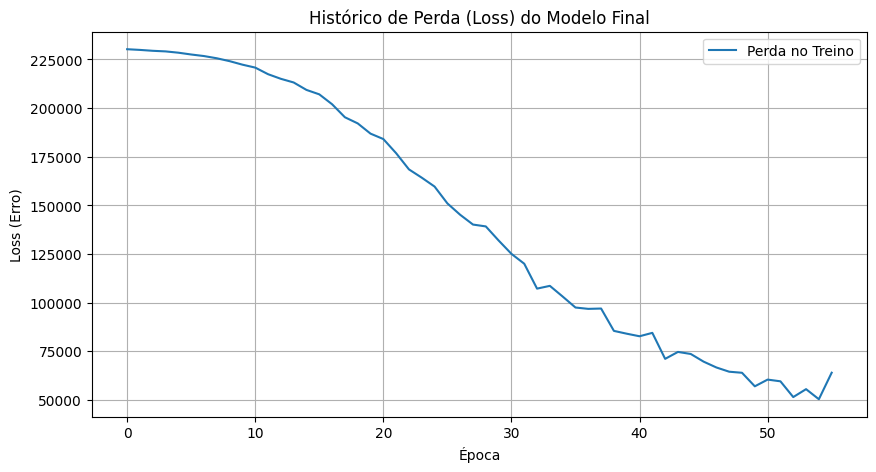


--- [ETAPA 5/5] Avaliação Final do Modelo no Conjunto de Teste ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step 

Métricas de Desempenho no Conjunto de Teste:
  - RMSE (Root Mean Squared Error): 539.47 pontos
  - MAE (Mean Absolute Error):      428.16 pontos
  - R² (R-squared):                 -0.3224


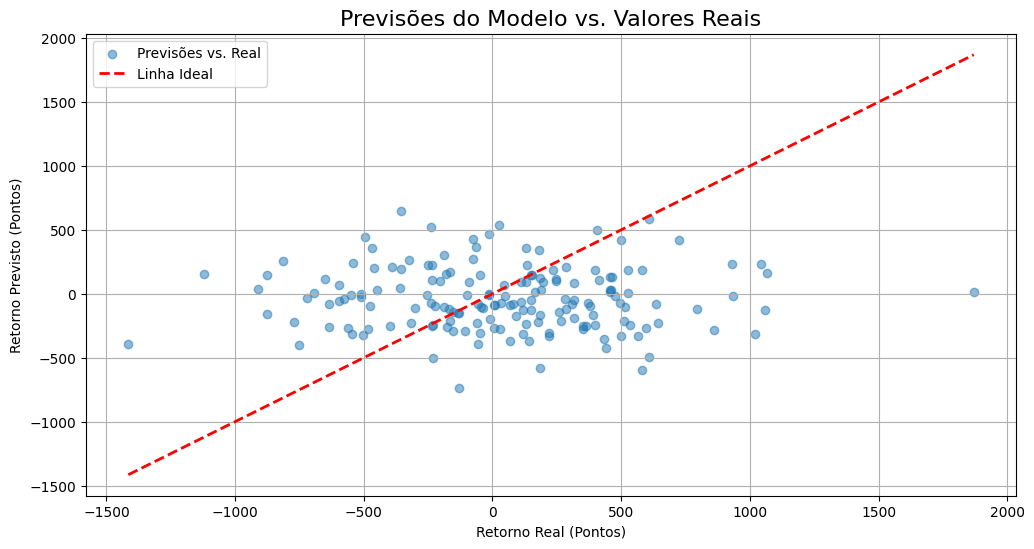

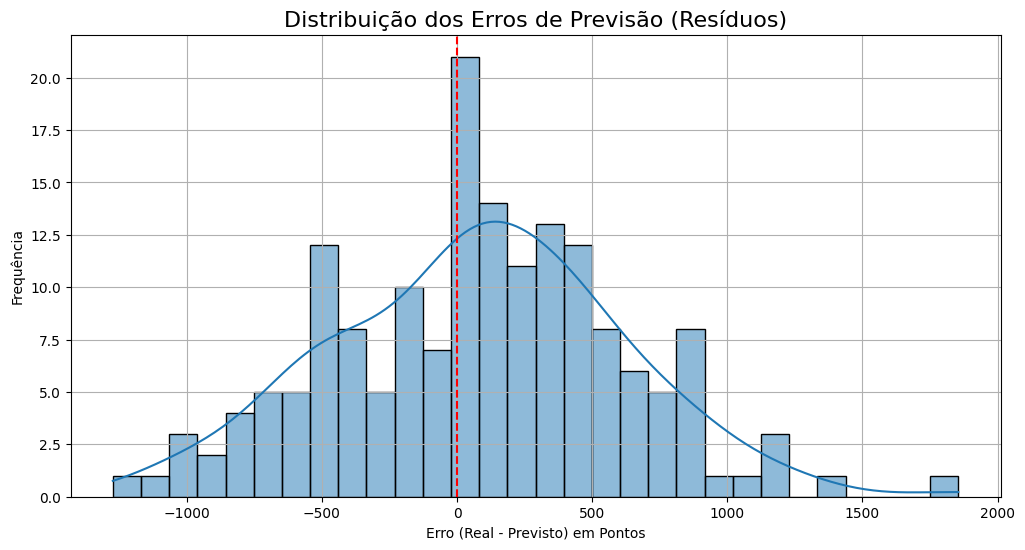

In [19]:
# ==============================================================================
# SCRIPT ÚNICO: OTIMIZAÇÃO, TREINAMENTO E AVALIAÇÃO DE CNN-LSTM PARA REGRESSÃO
# ==============================================================================

# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import re # Importa a biblioteca de expressões regulares
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Importações do TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, concatenate
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
print("--- [ETAPA 1/5] Carregando e Preparando os Dados ---")

NOME_ARQUIVO_DATASET = 'dataset_regressao_hibrido.csv'
# ATENÇÃO: Verifique se este valor corresponde ao número de velas no seu dataset (ex: 24 para M5, 120 para M1)
NUM_TIMESTEPS = 24 

try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0, parse_dates=True)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado. Verifique o nome e o caminho.")
    exit()

# 1.1 - Separação do Alvo (Y) e das Features (X)
Y = df[['retorno_direcional_alvo']]
X_flat = df.drop(columns=['retorno_direcional_alvo'])

# 1.2 - Identificação e Separação dos Tipos de Features (Método com Regex)
# Primeiro, identificamos as colunas que SÃO sequenciais usando um padrão de regex.
# O padrão r'_c\d+$' procura por colunas que terminam ('$') com '_c' seguido por um ou mais dígitos ('\d+').
sequential_cols = [col for col in X_flat.columns if re.search(r'_c\d+$', col)]

# As colunas de contexto/cíclicas são todas as outras.
context_ciclicas_cols = [col for col in X_flat.columns if col not in sequential_cols]

# Agora, podemos separar os DataFrames com segurança.
X_context = X_flat[context_ciclicas_cols]

# E obter os nomes base das features sequenciais a partir da lista já filtrada.
seq_feature_base_names = sorted(list(set(col.split('_c')[0] for col in sequential_cols)))

print(f"Features de Contexto/Cíclicas encontradas: {len(context_ciclicas_cols)}")
print(f"Nomes base de Features Sequenciais encontrados: {len(seq_feature_base_names)}")

# 1.3 - Reconstrução do Tensor 3D
NUM_SEQ_FEATURES = len(seq_feature_base_names)
X_seq = np.zeros((len(df), NUM_TIMESTEPS, NUM_SEQ_FEATURES))

print("Reconstruindo o tensor 3D a partir dos dados achatados...")
for i, base_name in enumerate(seq_feature_base_names):
    # Para cada nome base, seleciona todas as suas colunas sequenciais (de _c1 a _c<NUM_TIMESTEPS>)
    cols_to_select = [f'{base_name}_c{j+1}' for j in range(NUM_TIMESTEPS)]
    
    # Preenche a "fatia" correspondente do tensor 3D
    X_seq[:, :, i] = X_flat[cols_to_select].values

print(f"Dados reconstruídos: Contexto ({X_context.shape}), Sequencial ({X_seq.shape}), Alvo ({Y.shape})")

# 1.4 - Divisão em Treino, Validação e Teste (Cronológica)
indices = np.arange(len(Y))
train_val_indices, test_indices = train_test_split(indices, test_size=0.2, shuffle=False)
train_indices, val_indices = train_test_split(train_val_indices, test_size=0.2, shuffle=False)

X_context_train, X_context_val, X_context_test = X_context.iloc[train_indices], X_context.iloc[val_indices], X_context.iloc[test_indices]
X_seq_train, X_seq_val, X_seq_test = X_seq[train_indices], X_seq[val_indices], X_seq[test_indices]
y_train, y_val, y_test = Y.iloc[train_indices], Y.iloc[val_indices], Y.iloc[test_indices]

# 1.5 - Padronização (StandardScaler)
scaler_context = StandardScaler().fit(X_context_train)
X_context_train = scaler_context.transform(X_context_train)
X_context_val = scaler_context.transform(X_context_val)
X_context_test = scaler_context.transform(X_context_test)

scaler_seq = StandardScaler().fit(X_seq_train.reshape(-1, NUM_SEQ_FEATURES))
X_seq_train = scaler_seq.transform(X_seq_train.reshape(-1, NUM_SEQ_FEATURES)).reshape(X_seq_train.shape)
X_seq_val = scaler_seq.transform(X_seq_val.reshape(-1, NUM_SEQ_FEATURES)).reshape(X_seq_val.shape)
X_seq_test = scaler_seq.transform(X_seq_test.reshape(-1, NUM_SEQ_FEATURES)).reshape(X_seq_test.shape)

print("Dados prontos para o modelo.")

# --- ETAPA 2: OTIMIZAÇÃO COMPLETA COM OPTUNA ---
print("\n--- [ETAPA 2/5] Otimizando Hiperparâmetros com Optuna ---")

def create_model(trial):
    # --- Pré-definição de todos os hiperparâmetros possíveis ---
    # Parâmetros de Otimização
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    
    # Parâmetros da Arquitetura
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 3)
    n_lstm_layers = trial.suggest_int('n_lstm_layers', 1, 2)
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 3)
    context_dense_units = trial.suggest_int('context_dense_units', 16, 128, log=True)

    # O Optuna sugere um valor para l1 e l2. Vamos usá-los para criar um regularizador.
    l1_strength = trial.suggest_float('l1_strength', 1e-8, 1e-2, log=True)
    l2_strength = trial.suggest_float('l2_strength', 1e-8, 1e-2, log=True)
    kernel_regularizer = regularizers.l1_l2(l1=l1_strength, l2=l2_strength)

    # Parâmetros para até 3 camadas CNN
    conv_filters = [trial.suggest_int(f'conv_{i}_filters', 16, 128, log=True) for i in range(3)]
    conv_kernels = [trial.suggest_int(f'conv_{i}_kernel_size', 2, 7) for i in range(3)]
    # === NOVA ALTERAÇÃO AQUI ===
    conv_paddings = [trial.suggest_categorical(f'conv_{i}_padding', ['causal', 'same']) for i in range(3)]
    conv_pools = [trial.suggest_categorical(f'conv_{i}_pool_size', [1, 2, 3]) for i in range(3)]
    use_conv_dropouts = [trial.suggest_categorical(f'use_conv_{i}_dropout', [True, False]) for i in range(3)]
    conv_dropout_rates = [trial.suggest_float(f'conv_{i}_dropout_rate', 0.1, 0.9) for i in range(3)]

    # Parâmetros para até 2 camadas LSTM
    lstm_units = [trial.suggest_int(f'lstm_{i}_units', 32, 256, log=True) for i in range(2)]
    use_lstm_dropouts = [trial.suggest_categorical(f'use_lstm_{i}_dropout', [True, False]) for i in range(2)]
    lstm_dropout_rates = [trial.suggest_float(f'lstm_{i}_dropout_rate', 0.1, 0.9) for i in range(2)]

    # Parâmetros para até 3 camadas Dense
    dense_units = [trial.suggest_int(f'dense_{i}_units', 32, 256, log=True) for i in range(3)]
    use_dense_dropouts = [trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False]) for i in range(3)]
    dense_dropout_rates = [trial.suggest_float(f'dense_{i}_dropout_rate', 0.1, 0.9) for i in range(3)]

    # --- Construção do Modelo ---
    tf.keras.backend.clear_session()
    input_seq = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='input_sequencial')
    input_context = Input(shape=(X_context_train.shape[1],), name='input_contexto')
    
    # Ramo Sequencial
    current_seq = input_seq
    for i in range(n_conv_layers):
        # === APLICAÇÃO DO REGULARIZADOR ===
        current_seq = Conv1D(filters=conv_filters[i], kernel_size=conv_kernels[i], activation='relu', padding=conv_paddings[i], kernel_regularizer=kernel_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if use_conv_dropouts[i]:
            current_seq = Dropout(rate=conv_dropout_rates[i])(current_seq)
        
        pool_size = conv_pools[i]
        if current_seq.shape[1] > pool_size:
             current_seq = MaxPooling1D(pool_size=pool_size)(current_seq)
    
    for i in range(n_lstm_layers):
        return_sequences = (i < n_lstm_layers - 1)
         # === APLICAÇÃO DO REGULARIZADOR ===
        current_seq = LSTM(units=lstm_units[i], return_sequences=return_sequences, kernel_regularizer=kernel_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if use_lstm_dropouts[i]:
            current_seq = Dropout(rate=lstm_dropout_rates[i])(current_seq)

    # Ramo de Contexto
    input_context = Input(shape=(X_context_train.shape[1],), name='input_contexto')
    x_context = Dense(units=context_dense_units, activation='relu')(input_context)

    # Concatenação e Camadas Finais
    x = concatenate([current_seq, x_context])
    for i in range(n_dense_layers):
        x = Dense(units=dense_units[i], activation='relu', kernel_regularizer=kernel_regularizer)(x) # Adicionado regularizador que faltava
        if use_dense_dropouts[i]:
            x = Dropout(rate=dense_dropout_rates[i])(x)
            
    # --- Camada de Saída para Regressão ---
    # A saída deve ter 1 neurônio (para prever um único valor) e ativação 'linear'.
    output = Dense(1, activation='linear', name='output_regressao')(x)
    
    model = Model(inputs=[input_seq, input_context], outputs=output)
    
    # Seleciona o otimizador
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if optimizer_name == 'Adam' else tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    
    # ---  Compilação para Regressão ---
    # A função de perda (loss) deve ser uma de regressão, como 'mean_squared_error'.
    # A métrica também deve ser de regressão, como 'mae' (Mean Absolute Error).
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

def objective(trial):
    model = create_model(trial)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    model.fit(
        [X_seq_train, X_context_train], y_train,
        validation_data=([X_seq_val, X_context_val], y_val),
        epochs=150, # Um número alto, o EarlyStopping vai parar antes
        batch_size=batch_size,
        callbacks=[EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)],
        verbose=0
    )
    
    val_accuracy = model.evaluate([X_seq_val, X_context_val], y_val, verbose=0)[1]
    return val_accuracy

def objective(trial):
    model = create_model(trial)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    epochs = trial.suggest_int('epochs', 50, 200) # Optuna também pode otimizar o número de épocas
    
    history = model.fit([X_seq_train, X_context_train], y_train,
                        validation_data=([X_seq_val, X_context_val], y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
                        verbose=0)
    
    val_loss = min(history.history['val_loss'])
    return val_loss

# Cria e executa o estudo
study = optuna.create_study(direction='minimize')
############################################################
study.optimize(objective, n_trials=3) # 100 trials para uma busca robusta
############################################################
# --- ETAPA 3: ANÁLISE DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- [ETAPA 3/5] Análise dos Resultados da Otimização ---")

best_trial = study.best_trial
print(f"Otimização concluída! Melhor Loss de Validação (MSE): {best_trial.value:.2f}")
print("Melhores Hiperparâmetros:")
for key, value in best_trial.params.items():
    print(f"  - {key}: {value}")

# Visualizações do Optuna
print("\nGerando gráficos de análise da otimização...")
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.show()

fig2 = optuna.visualization.plot_param_importances(study)
fig2.show()

fig3 = optuna.visualization.plot_slice(study)
fig3.show()

# --- ETAPA 4: TREINAMENTO DO MODELO FINAL ---
print("\n--- [ETAPA 4/5] Treinando o Modelo Final com os Melhores Parâmetros ---")

final_model = create_model(best_trial)
final_batch_size = best_trial.params['batch_size']
final_epochs = best_trial.params['epochs']

X_seq_train_val = np.concatenate([X_seq_train, X_seq_val], axis=0)
X_context_train_val = np.concatenate([X_context_train, X_context_val], axis=0)
y_train_val = pd.concat([y_train, y_val])

history = final_model.fit([X_seq_train_val, X_context_train_val], y_train_val,
                          epochs=final_epochs,
                          batch_size=final_batch_size,
                          callbacks=[EarlyStopping(monitor='loss', patience=25, restore_best_weights=True)],
                          verbose=1)

print("Treinamento final concluído.")

# Gráfico de Perda do Treinamento Final
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Perda no Treino')
if 'val_loss' in history.history: # Se houver dados de validação no fit final
    plt.plot(history.history['val_loss'], label='Perda na Validação')
plt.title('Histórico de Perda (Loss) do Modelo Final')
plt.xlabel('Época')
plt.ylabel('Loss (Erro)')
plt.legend()
plt.grid(True)
plt.show()

# --- ETAPA 5: AVALIAÇÃO FINAL E MÉTRICAS ---
print("\n--- [ETAPA 5/5] Avaliação Final do Modelo no Conjunto de Teste ---")

y_pred = final_model.predict([X_seq_test, X_context_test])

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMétricas de Desempenho no Conjunto de Teste:")
print(f"  - RMSE (Root Mean Squared Error): {rmse:.2f} pontos")
print(f"  - MAE (Mean Absolute Error):      {mae:.2f} pontos")
print(f"  - R² (R-squared):                 {r2:.4f}")

# Gráfico de Previsões vs. Valores Reais
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Previsões vs. Real')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Linha Ideal')
plt.title('Previsões do Modelo vs. Valores Reais', fontsize=16)
plt.xlabel('Retorno Real (Pontos)')
plt.ylabel('Retorno Previsto (Pontos)')
plt.legend()
plt.grid(True)
plt.show()

# Gráfico da Distribuição dos Erros (Resíduos)
plt.figure(figsize=(12, 6))
residuals = y_test.values.flatten() - y_pred.flatten()
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribuição dos Erros de Previsão (Resíduos)', fontsize=16)
plt.xlabel('Erro (Real - Previsto) em Pontos')
plt.ylabel('Frequência')
plt.axvline(0, color='red', linestyle='--')
plt.grid(True)
plt.show()


# **modelagem de componentes**
Essa é uma abordagem muito interessante e sofisticada, conhecida como **modelagem de componentes** ou, em alguns contextos, como um tipo de **modelo de mistura de especialistas (mixture of experts)**.

A ideia é dividir um problema complexo (prever um movimento direcional) em dois sub-problemas potencialmente mais fáceis:

1.  **Modelo 1 (Regressão):** Prever a **magnitude** do movimento (a volatilidade, o "tamanho da vela").
2.  **Modelo 2 (Classificação Binária):** Prever a **direção** do movimento (para cima ou para baixo).

Depois, você combina as saídas dos dois modelos para obter sua previsão final. Vamos analisar essa arquitetura em detalhes.

---

## A Arquitetura de Dois Modelos

### Modelo 1: Regressor de Magnitude (Volatilidade)

*   **Tarefa:** Regressão.
*   **Label (Alvo `Y`):** `abs(Fechamento_12h - Abertura_11h)` ou `(Maxima_11h_12h - Minima_11h_12h)`. O valor absoluto do retorno é uma boa escolha.
*   **Objetivo:** Prever o tamanho do movimento em pontos, independentemente da direção. O valor previsto será sempre positivo.
*   **Métrica de Otimização:** `RMSE` ou `MAE` (minimizar).

### Modelo 2: Classificador de Direção

*   **Tarefa:** Classificação Binária.
*   **Label (Alvo `Y`):**
    *   `+1` se `(Fechamento_12h - Abertura_11h) > 0` (movimento de alta).
    *   `-1` (ou `0`) se `(Fechamento_12h - Abertura_11h) < 0` (movimento de baixa).
    *   **Importante:** Você precisa decidir o que fazer com os dias de movimento muito pequeno (laterais). Uma abordagem comum é criar uma "zona morta":
        *   `+1` se `Retorno > Threshold_Pontos`
        *   `-1` se `Retorno < -Threshold_Pontos`
        *   Excluir os dias entre `-Threshold` e `+Threshold` do treinamento deste modelo, pois são ambíguos.
*   **Objetivo:** Prever apenas se o mercado vai subir ou descer.
*   **Métrica de Otimização:** `Acurácia`, `AUC` ou `F1-Score` (maximizar).


## Como Combinar as Previsões

Uma vez que você tenha os dois modelos treinados, para um novo dia, você faz:

1.  **Previsão de Magnitude:** O Modelo 1 prevê, por exemplo, `250` (pontos).
2.  **Previsão de Direção:** O Modelo 2 prevê, por exemplo, `+1` (alta).
3.  **Previsão Final Combinada:** `Previsão Final = 250 * (+1) = +250 pontos`.


## Por que é uma **BOA OPÇÃO** (e frequentemente usada por profissionais)?

1.  **Foco e Especialização (Princípio da Responsabilidade Única):**
    *   Prever direção e magnitude ao mesmo tempo é pedir para um único modelo ser bom em duas coisas muito diferentes. A direção pode depender mais de indicadores de momento (RSI, MACD), enquanto a magnitude pode depender mais de indicadores de volatilidade (ATR, Bandas de Bollinger).
    *   Ao separar, você permite que cada modelo se especialize, potencialmente aprendendo relações mais sutis e se tornando mais preciso em sua única tarefa.

2.  **Flexibilidade na Escolha da Ferramenta:**
    *   Você pode descobrir que um modelo **XGBoost** é um classificador de direção fantástico (ótimo em encontrar fronteiras de decisão), mas não é tão bom em prever valores contínuos.
    *   Ao mesmo tempo, uma **Rede Neural (LSTM)** pode ser excelente em capturar a dinâmica da volatilidade (regressão), mas se confunde com a classificação.
    *   Separar os modelos te dá a liberdade de usar **a melhor ferramenta para cada trabalho**, em vez de forçar uma única ferramenta a fazer tudo.

3.  **Controle de Risco e Interpretabilidade:**
    *   Esta arquitetura te dá mais controle. Você pode criar uma regra de trading como: "Só operar se o modelo de direção disser 'Compra' E o modelo de magnitude prever um movimento > 200 pontos". Isso filtra operações em períodos de baixa volatilidade, que podem ser menos lucrativos ou mais arriscados.
    *   Se o sistema falha, você pode diagnosticar mais facilmente: "O erro foi na direção ou na magnitude?".


## Por que pode ser considerada uma **OPÇÃO COMPLEXA** (e não necessariamente "péssima")?

1.  **Aumento da Complexidade do Pipeline:**
    *   Em vez de um pipeline (Engenharia de Dados -> Otimização -> Treino -> Avaliação), você agora tem **dois pipelines paralelos**. Isso significa mais código para escrever, mais modelos para gerenciar, mais hiperparâmetros para otimizar e mais pontos de falha.

2.  **Erro Composto:**
    *   A sua previsão final depende de **ambos os modelos estarem certos**. Se o modelo de direção acerta (+1), mas o de magnitude erra feio (prevê 1000 quando foi 100), sua posição pode ser muito grande ou pequena. Se o de magnitude acerta (prevê 500), mas o de direção erra (-1 em vez de +1), você entra na direção oposta. O erro total pode ser maior do que o de um único modelo que aprende a balancear os dois objetivos internamente.

3.  **Potencial de Perda de Informação:**
    *   Existe a possibilidade teórica de que a **interação** entre a direção e a magnitude seja uma informação importante. Um único modelo de regressão que prevê o retorno direcional (`-500` ou `+500`) pode aprender que "certos padrões levam a movimentos grandes *e* negativos", uma informação que pode ser parcialmente perdida quando os dois problemas são separados.

---

### Veredito Final: **É uma Boa Opção, mas para a Etapa Certa do Projeto.**

*   **Para um Primeiro Protótipo:** Começar com um **único modelo de regressão** (prevendo o retorno direcional) é mais simples e rápido. Ele estabelece uma linha de base (um "benchmark") de performance.

*   **Para Melhorar a Performance (Seu Estágio Atual):** Agora que você já tem um benchmark e viu as limitações do modelo único, **explorar a arquitetura de dois modelos é o próximo passo lógico e profissional.** É uma forma de tentar "desatar o nó" do problema, permitindo que especialistas resolvam as partes mais fáceis.

**Conclusão:** Não é uma péssima opção. É uma **estratégia avançada e inteligente**. A palavra "medo" na sua pergunta é interessante. Não há motivo para ter medo dessa abordagem. Encare-a como uma hipótese a ser testada:

> **Hipótese:** "Separar a previsão de magnitude da previsão de direção resultará em um sistema combinado com performance superior à de um único modelo de regressão."

Seu trabalho agora é conduzir o experimento para validar ou refutar essa hipótese.
